<a href="https://colab.research.google.com/github/davidq932-code/connectatel-user-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [73]:
# importar librerías
import pandas as pd


In [74]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv') #completa el código
usage = pd.read_csv('usage.csv') #completa el código

In [75]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [76]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [77]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.



### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.



In [78]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [79]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [80]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [81]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [82]:


# cantidad de nulos para users
print(users.isna().sum())

print(users.isna().mean())




user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [83]:
# cantidad de nulos para usage
print(usage.isna().sum())

print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  los datos de users los cuales son 4000 entries:
    churn_date 3534 entries de nulos con el 88.35 % de los datos.
    city 469 entries de nulos con el 11.72 % de los datos.

  los datos de usage los cuales son 40000 entries:
    date 50 entries de nulos con el 0.12%  de los datos.
    duration 22076 entries de nulos con el 55.19% de los datos.
    length 17896 entries de nulos con el 44.74% de los datos.
    
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
  los datos de users:
    churn_date se pueden eliminar o ignorar ya que corresponde a usuarios que pueden estar activos o no se han dado de baja.
    city investigar para imputar o dejar como nulos, para tener un area mas definido de que lugar corresponden los usuarios.

  los datos de usage:
    date se pueden ignorar o eliminar la cantidad es muy poca de datos que se puedan ver afectados.
    duration ignorarlos o eliminarlos ya que corresponde a las llamadas realizadas en tiempo y estos estan nulos al ser mensajes de texto.
    length ignorarlos o eliminarlos ya que corresponde a el tamaño de los mensajes de texto y estos estan nulos por las llamadas realizadas.

con ya tener especificado que son call o text se puede hacer una separacion en los casos de duration y length.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [84]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`nos ayuda a identificar cada usuario.
- La columna `age` en este caso si se aprecia un valor sentinel con minimo de -999, el cual no crresponde a una edad valida.

In [85]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` corresponden a identificadores, id es para registros individuales y user_id es para los registros individuales agrupados por usuarios.
- Las columnas duration y length presentan una cantidad menor de entries comparada con el total, ya que como se comentaba en los valores nulos cada uno corresponde a categorias unicas se debe realizar un promedio unico entre dichas categorias.

In [86]:


# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nValores unicos de {columna}:")
    print(users[columna].unique())

    print(f"\nFrecuencia de {columna}:")
    print(users[columna].value_counts())




Valores unicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Frecuencia de city:
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Valores unicos de plan:
['Basico' 'Premium']

Frecuencia de plan:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


- La columna `city` contiene siete categorias de ciudades y presenta 2 tipos de valores faltantes o desconocidos, 469 valores nan o nulos y 96 registros "?" que podria corresponder a un sentinel utilizado para representar informacion desconocida.
- La columna `plan` se observan dos categorias:basico y premium. no se observan inconsistencias o valores nulos.

In [87]:
# explorar columna categórica de usage
def valores_invalidos(df, columnas):
    for columna in columnas:
        print(f"\nValores unicos de {columna}:")
        print(df[columna].unique())

        print(f"\nFrecuencia de {columna}:")
        print(df[columna].value_counts())
valores_invalidos(usage, ['type'])



Valores unicos de type:
['call' 'text']

Frecuencia de type:
type
text    22092
call    17908
Name: count, dtype: int64


- La columna `type` se observan dos categorias: text y call. no se observan inconsistencias o valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  en la columna city se observan valores inválidos o sentinels.
- ¿Qué acción tomarías?
   los valores "?" con 96 registros se deberian asignar a nulos ya que puede referirse a informacion desconocida.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [88]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código


In [89]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [90]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


En reg_dates se observan fechas entre 2022 y 2024. Los 40 registros correspondientes a 2026 están fuera del rango esperado, por lo que se consideran inválidos y pueden excluirse del análisis.  haz doble clic en este bloque y escribe qué ves.

In [91]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

date
2024.0    39950
NaN          50
Name: count, dtype: int64


En `date`, solo hay fechas del 2024 y 50 valores nulos. ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos

  solo se dispone en usage 'date' datos del año 2024 lo cual solo nos deja analizar los datos de ese año con relacion a `reg_date` de users.
  en users `reg_date` se haya un faltante del año 2025 de los registros y se observan valores en el año 2026 que pueden ser fechas futuras.

- ¿Qué harías con ellas?

  centraria el analisis en el año 2024 al ser el unico con el cual puedo relacionar la informacion.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [92]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [93]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

,city
count,3435
unique,6
top,Bogotá
freq,808


In [94]:

# Marcar fechas futuras como NA para reg_date

hoy = pd.Timestamp.today()
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].describe())


count                             3960
mean     2023-07-03 21:39:41.095273728
min                2022-01-01 00:00:00
25%      2022-10-02 20:17:11.657914368
50%      2023-07-04 10:00:05.401350400
75%      2024-04-03 04:00:05.401350400
max                2024-12-31 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [95]:

# Verificación MAR en usage (Missing At Random) para duration
usage['durtation_missing'] = usage['duration'].isna()
print(
    usage.groupby('type')['durtation_missing'].mean())


type
call    0.000000
text    0.999276
Name: durtation_missing, dtype: float64


In [96]:
# Verificación MAR en usage (Missing At Random) para length
usage['durtation_missing'] = usage['length'].isna()
print(
    usage.groupby('type')['durtation_missing'].mean())

type
call    0.99933
text    0.00000
Name: durtation_missing, dtype: float64


al analizar los valores faltantes de `duration` y `length` segun la variable type, se observa una relacion clara entre el tipo de registro y la presencia de nulos. En los registros de tipo call, duration presenta valores disponibles, mientras que length es prácticamente nulo. En los registros de tipo text, ocurre el patrón contrario: length presenta valores disponibles y duration es prácticamente nulo.
Esto indica que los valores faltantes están relacionados con el tipo de registro y no necesariamente representan errores en los datos. Por esta razón, los valores nulos se mantienen sin imputación, ya que reemplazarlos por la media, mediana o cero podría introducir información que no corresponde al tipo de registro.

Además, la variable type permite diferenciar los registros de llamadas y mensajes, por lo que estas observaciones pueden utilizarse para agrupar o analizar a los usuarios según el tipo de actividad que realizan.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [97]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call":"sum",
    "duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [98]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call":"cant_llamadas",
    "duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [99]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [100]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [101]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

,proportion
plan,
Basico,64.875
Premium,35.125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

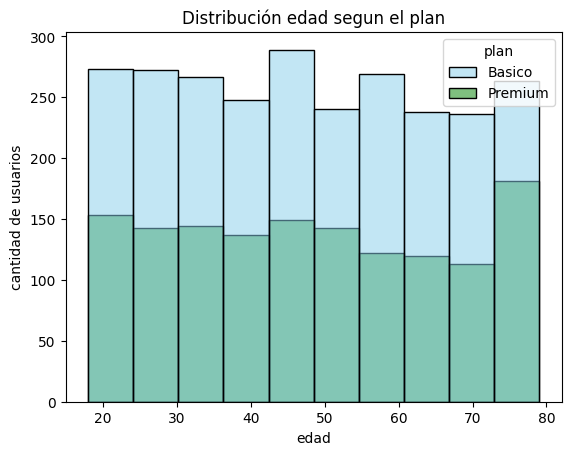

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=10
)
plt.title('Distribución edad segun el plan')
plt.xlabel('edad')

plt.ylabel('cantidad de usuarios')
plt.show()


💡Insights:
- Distribución de las edades es aproximadamente simetrica tanto para los usuarios del plan Basico como para los del plan Premium. ambos presentan una distribucion de edades relativamente equilibrada, sin un sesgo evidente hacia edades bajas o altas.

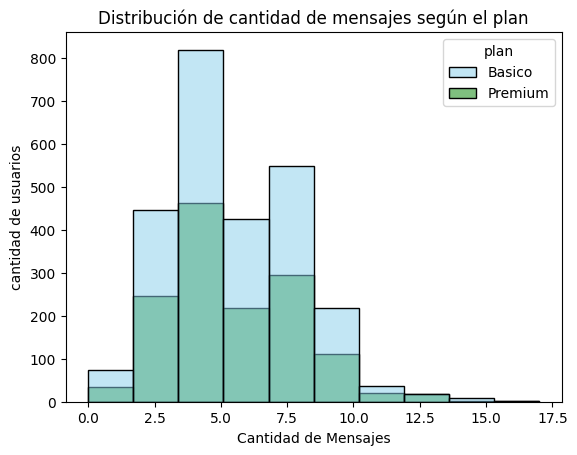

In [103]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=10)

plt.title('Distribución de cantidad de mensajes según el plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('cantidad de usuarios')
plt.show()


💡Insights:
- la Distribución de cantidad de mensajes según el plan presenta un sesgo hacia la derecha, ya que la mayor concentracion de usuarios se encuentra en los rangos bajos de mensajes y, a medida que aumenta la cantidad de mensajes, la frecuencia de usuarios disminuye, formando una cola hacia la derecha, la barra mas alta conecta aproximadamente 800 usuarios.
- al comprar los planes basico y premium no se observa una diferencia marcada, ya que ambos presentan una distribucion similar y cada uno representa casi la mitad de los usuarios en los diferentes rangos.

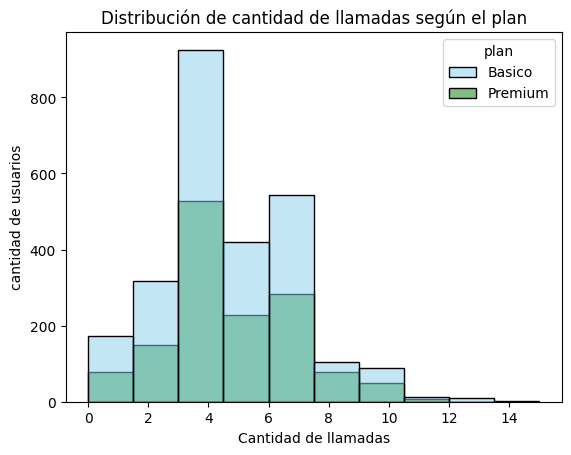

In [104]:

# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=10)

plt.title('Distribución de cantidad de llamadas según el plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('cantidad de usuarios')
plt.show()




💡Insights:
- la Distribución de cantidad de llamadas según el plan presenta un sesgo hacia la derecha, ya que la mayor concentración de usuarios se encuentra en los rangos bajos de llamadas y, a medida que aumenta la cantidad de llamadas, la frecuencia de usuarios disminuye, formando una cola hacia la derecha, la barra mas alta concentra aproximadamente mas de 800 usuarios, centrándose en 4 llamadas.
- al comparar los planes basico y premium no se observa una diferencia marcada, ya que ambos presentan una distribucion similar y cada uno representa casi la mitad de los usuarios en los diferentes rangos.


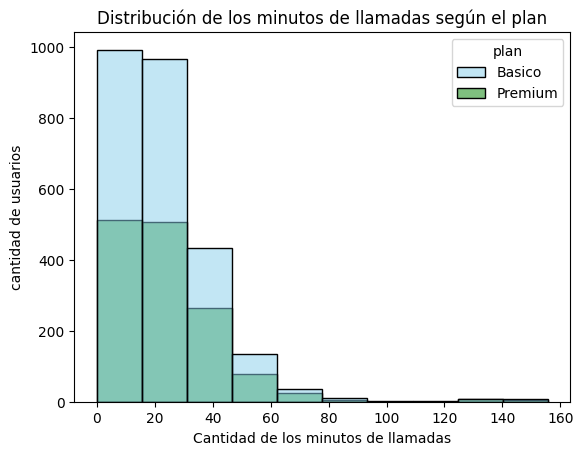

In [105]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=10)

plt.title('Distribución de los minutos de llamadas según el plan')
plt.xlabel('Cantidad de los minutos de llamadas')
plt.ylabel('cantidad de usuarios')
plt.show()


💡Insights:
- La distribución de los minutos de llamada según el plan presenta un sesgo hacia la derecha, ya que la mayor concentración de usuarios se encuentra en los rangos bajos de minutos de llamada. A medida que aumenta la cantidad de minutos, la frecuencia de usuarios disminuye, formando una cola hacia la derecha. La barra más alta concentra aproximadamente 1.000 usuarios y se encuentra dentro del rango de los primeros 20 minutos de llamadas.
- Al comparar los planes Básico y Premium, no se observa una diferencia marcada, ya que ambos presentan una distribución similar en los diferentes rangos de minutos de llamada.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

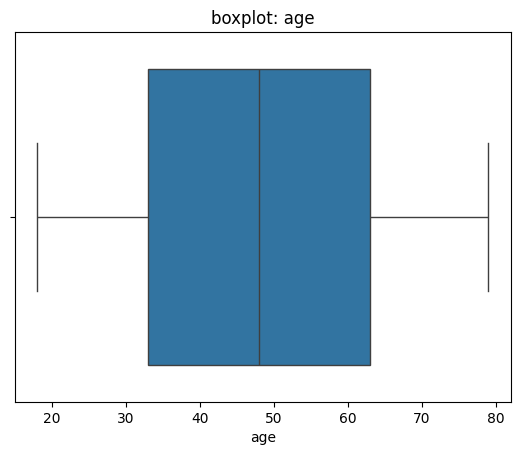

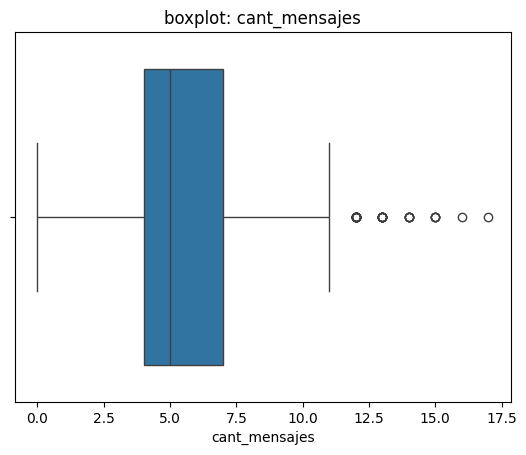

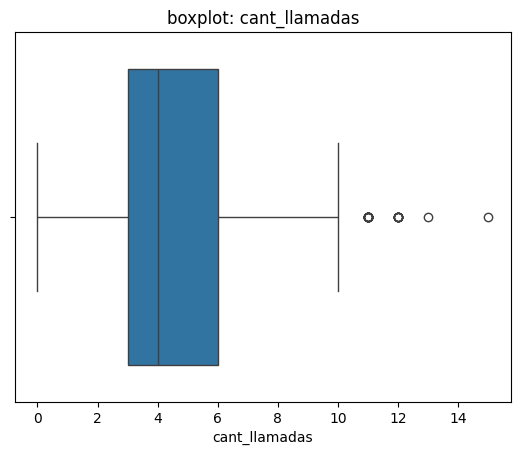

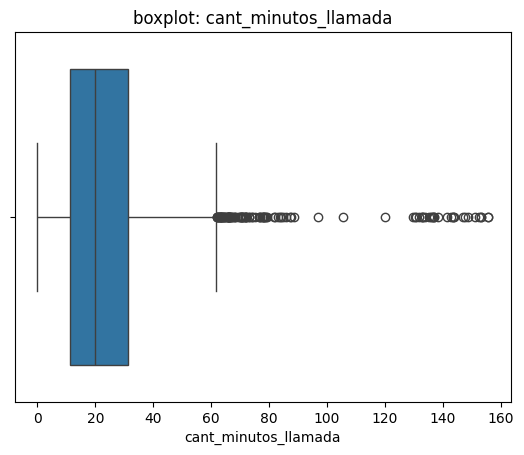

In [106]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no se observan puntos alejados por fuera de los bigotes. los datos se encuentran relativamente concentrados alrededor de la mediana, por lo que no se identifican outliers visualmente.
- cant_mensajes: la distribucion presenta una concentracion de usuarios en cantidades bajas de mensajes y una extension hacia valores altos. Se observan algunos puntos alejados por encima del bigote superior, por lo que existen posibles outliers hacia la derecha.
- cant_llamadas: La mayor concentración de usuarios se encuentra en cantidades bajas de llamadas y la distribución se extiende hacia valores altos. Se observan algunos puntos por encima del bigote superior, por lo que existen posibles outliers hacia la derecha.
- cant_minutos_llamada: Presenta una distribución claramente extendida hacia valores altos. El 50% central de los datos se concentra aproximadamente alrededor de los primeros 20 minutos, mientras que se observan numerosos puntos por encima del bigote superior. Por lo tanto, presenta una cantidad considerable de posibles outliers hacia la derecha.

In [107]:

# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    print(f'\n{col}')
    print('Q1:', Q1)
    print('IQR:', IQR)
    print('Limite superior:', limite_superior)


age
Q1: 33.0
IQR: 30.0
Limite superior: 108.0

cant_mensajes
Q1: 4.0
IQR: 3.0
Limite superior: 11.5

cant_llamadas
Q1: 3.0
IQR: 3.0
Limite superior: 10.5

cant_minutos_llamada
Q1: 11.12
IQR: 20.295
Limite superior: 61.8575


In [108]:



# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()




,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? mantenerlos, porque una cantidad alta de mensajes puede representar un comportamiento real de algunos usuarios y no necesariamente un error de los datos.
- cant_llamadas: mantener o no outliers, porqué?
  mantenerlos, por que un usuario que realiza muchas llamadas puede ser un usuario real con un nivel de actividad mayor a el promedio, no hay evidencia de que sean errores.
- cant_minutos_llamada: mantener o no outliers, porqué?
  aquí la diferencia es mucho mayor: hay valores bastante superiores al limite superior.
  Decisión: mantenerlos, por que pueden representar usuarios que realizan llamadas considerablemente mas largas. son valores extremos. no tenemos evidencia de que sean errores.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [109]:
# Crear columna grupo_uso
import numpy as np
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones, valores, default='alto uso'
)


In [110]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [111]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]
valores = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)

In [112]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

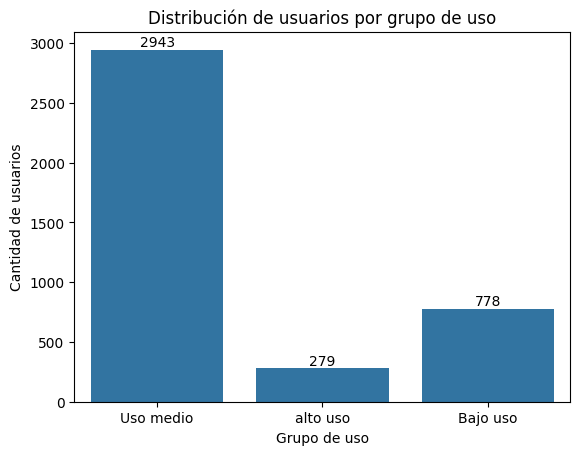

In [113]:
# Visualización de los segmentos por uso

ax = sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )
plt.show()


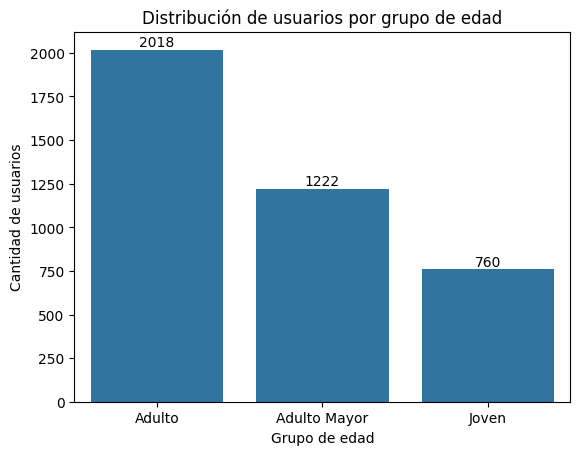

In [114]:
# Visualización de los segmentos por edad
ax = sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
-
¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En users se encontraron valores faltantes en city (0.11725 %) y churn_date (0.88350 %). El valor "?" de city se trató como dato desconocido.
- En usage se encontraron valores faltantes en date (0.00125 %), duration (0.55190 %) y length (0.44740 %).
- Los faltantes de duration y length se relacionan con el tipo de registro: duration corresponde a llamadas y length a mensajes, por lo que no se consideraron errores que debieran imputarse.
- Se encontraron outliers superiores en cant_mensajes, cant_llamadas y especialmente en cant_minutos_llamada, cuyo máximo alcanza 155.69 minutos frente a un límite superior IQR aproximado de 61.86.
Estos valores pueden representar usuarios reales con un consumo elevado, por lo que se decidió mantenerlos. Para ConnectaTel, pueden ser una oportunidad para identificar clientes que requieren planes con mayor capacidad.


🔍 **Segmentos por Edad**
- Se identificaron tres grupos: Joven, Adulto y Adulto Mayor.  El grupo más numeroso es Adulto, con más de 2.018 usuarios, seguido por Adulto Mayor con aproximadamente 1.222 y Joven con alrededor de 760.

📊 **Segmentos por Nivel de Uso**
- La mayor concentración corresponde a Uso medio, con aproximadamente 2.943 usuarios. Le siguen Bajo uso, con cerca de 778, y Alto uso, con menos de 279 usuarios.

➡️ Esto sugiere que la mayoría de los clientes presenta un nivel de consumo intermedio.
- El grupo de Uso medio representa la mayor cantidad de clientes, por lo que es importante para estrategias de retención. Los usuarios de Alto uso, aunque son menos numerosos, presentan un consumo mayor y pueden representar una oportunidad para planes con mayores límites de llamadas, mensajes y minutos.


💡 **Recomendaciones**
-  Mantener una oferta dirigida al segmento de Uso medio, por ser el más numeroso.
-  Analizar planes con mayores límites para los usuarios de Alto uso.
-  Considerar diferentes ofertas según los grupos de edad, especialmente para el grupo Adulto Mayor, que es el más numeroso.
-  Cruzar grupo_edad y grupo_uso para identificar perfiles específicos y diseñar ofertas más personalizadas.
-  Monitorear los usuarios con consumos extremos para determinar si requieren planes especializados.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/davidq932-code/connectatel-user-analysis/blob/main/S7%20Version-Estudiante-Project-ConnectaTel.ipynb`